# Issue #272, part 3: two review comparisons from PR #363, on the real `cnn_vit_cnn` model

Companion to [`issue_272_rollout_bug.ipynb`](issue_272_rollout_bug.ipynb) (the bug,
on synthetic data) and
[`issue_272_train_compare.ipynb`](issue_272_train_compare.ipynb) (old vs. fixed
rollout, on real data, with a toy 1x1-conv processor).

This notebook answers two comparisons requested in review on
[PR #363](https://github.com/alan-turing-institute/icenet-mp/pull/363), using the
real production model components (`CNNEncoder` + `VitProcessor` + `CNNDecoder`, i.e.
the `cnn_vit_cnn` model config) instead of a toy processor:

1. **Collapsing the history window into `N` (batch) vs. `C` (channels).** The PR's
   fix concatenates the history window along channels before calling the processor's
   `forward`. This raises the question of whether collapsing into the batch
   dimension instead might also work.
2. **Fixed vs. current `main` (the pre-#272 FIFO rollout).** This comparison shows
   the effect size of the fix, not to gate merging a correctness fix on it
   "winning".

Three processor variants are trained end-to-end (same `CNNEncoder` in, same
`CNNDecoder` out, same optimizer/data/epochs) on real SSMIS sea ice concentration
data, differing only in how the processor's `rollout` handles the history window:

| Variant | How the window is handled | Corresponds to |
|---|---|---|
| `old_fifo` | Single frame at a time, FIFO queue | `main` before PR #363 |
| `n_collapse` | Each frame run independently (batch), averaged | Alternative collapse strategy |
| `c_collapse` | Whole window concatenated on channels | PR #363 (shipped fix) |

**Scale note:** the real `VitProcessor` at the production latent size (144x144) is
much more expensive to train than the toy processors in the companion notebooks, so
this notebook uses a shorter forecast horizon (6 days, not 14) and fewer epochs than
a real training run would use. The point here is to isolate and illustrate the
architectural difference between the three rollout strategies, not to produce a
publication-quality skill score.

In [ ]:
import os

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # antialiased resize backward isn't
                                                   # implemented on MPS yet; fall back
                                                   # to CPU for that one op only.

import time

import numpy as np
import torch
from anemoi.datasets import open_dataset
from torch import nn
from torch.utils.data import DataLoader, Dataset

from icenet_mp.models.decoders.cnn_decoder import CNNDecoder
from icenet_mp.models.encoders.cnn_encoder import CNNEncoder
from icenet_mp.models.processors.vit import VitProcessor
from icenet_mp.types import DataSpace, ProcessorOutput

# Work around a fragile background telemetry pool in anemoi.datasets: open_dataset()
# unconditionally fires an analytics ping via a single-worker ProcessPoolExecutor
# created at import time. If that one worker process ever dies (plausible over a long
# Jupyter session with MPS activity/interrupted training runs), every subsequent
# open_dataset() call raises BrokenProcessPool, unrelated to our data/code. Analytics
# is already disabled locally (~/.config/anemoi/analytics.json) -- this just makes
# that opt-out crash-proof instead of a no-op that still touches the broken pool.
import anemoi.datasets.usage.analytics as _anemoi_analytics


class _NoOpExecutor:
    def submit(self, fn, *args, **kwargs):
        return None


_anemoi_analytics._executor = _NoOpExecutor()

torch.manual_seed(0)

ZARR = "/Volumes/Storage/ClimateData/data/anemoi/full-sicnorth-ssmis-25p0km-1979-2024-24h-v2.zarr"
N_HISTORY = 3
N_FORECAST = 6
BATCH_SIZE = 8
N_EPOCHS = 10
LATENT_SPACE = (144, 144)  # matches icenet_mp/config/model/cnn_vit_cnn.yaml
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {DEVICE}")

## 1. Data: real SSMIS sea ice concentration, 1999 onwards

Same split as `issue_272_train_compare.ipynb`, but a different source: the
single-channel `ice_conc` variable from the SSMIS zarr (`group_as: sic-ssmis`,
matching `predict=sic-ssmis-14d`'s target), not the OSI-SAF zarr (`sic-icenet`) that
notebook and the companion `issue_272_train_compare.ipynb` use. SSMIS is the source
the "standard" full-north training command actually targets. Same native 432x432
EASE2 25km grid, split chronologically so no window crosses a split boundary. The
SSMIS zarr carries several other variables (uncertainties, raw values, status flag)
alongside `ice_conc`, so we select it explicitly rather than assuming a single-variable
store.

- **Train**: 1999-2014 (16 years)
- **Validate**: 2015-2017 (not used in this demo)
- **Test**: 2018-2020 (held out, used for the comparison below)

In [6]:
print("Loading real SIC data from disk (one-time cost, ~1 minute)...")
t0 = time.time()
# select=["ice_conc"]: unlike the OSI-SAF zarr this notebook used to load, the SSMIS
# zarr stores 6 variables (uncertainties, raw values, status flag, ice_conc); without
# an explicit select the reshape below would silently interleave them as if they were
# extra timesteps. fill_missing_dates="interpolate": SSMIS has one missing date inside
# this range (2000-12-01) -- without this, indexing across it raises MissingDateError.
ds = open_dataset(ZARR, select=["ice_conc"], fill_missing_dates="interpolate")
dates = list(ds.dates)
# SSMIS timestamps are at 12:00 (the OSI-SAF zarr this notebook used to load was at
# 00:00), so an exact `dates.index(np.datetime64("1999-01-01"))` lookup raises
# ValueError; match on day precision instead.
dates_by_day = np.array(dates, dtype="datetime64[D]")
idx_start = int(np.searchsorted(dates_by_day, np.datetime64("1999-01-01")))
idx_end = int(np.searchsorted(dates_by_day, np.datetime64("2020-12-31"), side="right") - 1)
raw = ds[idx_start : idx_end + 1].reshape(-1, 432, 432)  # (T, H, W)
sic = torch.from_numpy(np.ascontiguousarray(raw)).float()
split_dates = np.array(dates[idx_start : idx_end + 1])
print(f"Loaded {sic.shape[0]} days in {time.time() - t0:.1f}s, shape {tuple(sic.shape)}")

Loading real SIC data from disk (one-time cost, ~1 minute)...


BrokenProcessPool: A child process terminated abruptly, the process pool is not usable anymore

In [ ]:
# SSMIS timestamps are at 12:00, not midnight, so compare split boundaries by
# calendar day rather than exact instant (otherwise the day-of the boundary itself
# lands on the wrong side of the split).
split_dates_by_day = split_dates.astype("datetime64[D]")
train_end = np.searchsorted(split_dates_by_day, np.datetime64("2014-12-31"), side="right")
val_end = np.searchsorted(split_dates_by_day, np.datetime64("2017-12-31"), side="right")
print(f"train: {split_dates[0]} to {split_dates[train_end - 1]} ({train_end} days)")
print(f"validate: {split_dates[train_end]} to {split_dates[val_end - 1]} ({val_end - train_end} days)")
print(f"test: {split_dates[val_end]} to {split_dates[-1]} ({len(split_dates) - val_end} days)")


class WindowedSicDataset(Dataset):
    '''Slides (history, target) windows over an in-memory SIC tensor.'''

    def __init__(self, sic_thw: torch.Tensor, n_history: int, n_forecast: int) -> None:
        self.sic = sic_thw
        self.n_history = n_history
        self.n_forecast = n_forecast

    def __len__(self) -> int:
        return self.sic.shape[0] - self.n_history - self.n_forecast + 1

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        history = self.sic[idx : idx + self.n_history].unsqueeze(1)
        target = self.sic[
            idx + self.n_history : idx + self.n_history + self.n_forecast
        ].unsqueeze(1)
        return {"history": history, "target": target}


train_ds = WindowedSicDataset(sic[:train_end], N_HISTORY, N_FORECAST)
val_ds = WindowedSicDataset(sic[train_end:val_end], N_HISTORY, N_FORECAST)
test_ds = WindowedSicDataset(sic[val_end:], N_HISTORY, N_FORECAST)
print(f"train/val/test windows: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")

## 2. Three processor variants, one shared `VitProcessor` implementation

All three variants share the exact same `VitProcessor.__init__`/`forward` (patch
embedding, transformer blocks, decoder head) from the real, shipped
`icenet_mp.models.processors.VitProcessor` -- nothing about the network architecture
itself is reimplemented. What differs is only `rollout`, i.e. how the history window
is fed to that network:

- **`c_collapse`**: this is the real, unmodified `VitProcessor` -- its `rollout` is
  inherited from `BaseProcessor.rollout`, which after PR #363 concatenates the
  current window of frames along the *channel* dimension before each call to
  `forward`, then slides the window forward. This is literally the PR's shipped code.
- **`old_fifo`**: `forward` is built for a *single* frame's worth of channels
  (`patch_embed` sized for `data_space.channels`, not `* n_history_steps`) -- the
  interface every processor used before this PR. `rollout` is the original
  single-frame FIFO queue: pop the oldest frame, predict, push the prediction onto
  the back. This is `BaseProcessor.rollout` as it existed on `main` before the fix
  (reproduced here since the shipped version is now the sliding-window fix).
- **`n_collapse`**: also single-frame `forward`, but `rollout` collapses the window
  into the *batch* dimension instead: all `n_history_steps` frames are run through
  `forward` independently (no cross-frame mixing, since `Conv2d`/patch-embedding
  treat batch elements independently), and the resulting `n_history_steps`
  independent single-frame predictions are averaged to produce the next frame. This
  is an alternative collapse strategy raised in review -- there's no single canonical way
  to turn `n_history_steps` independent predictions back into one, so averaging is
  our choice of reduction; that ambiguity is itself part of the argument against this
  approach.

In [ ]:
class OldFifoVitProcessor(VitProcessor):
    '''Real VitProcessor, but forward() takes a single frame and rollout() is the
    original single-frame FIFO queue (BaseProcessor.rollout before PR #363).'''

    def __init__(self, *, n_history_steps: int, **kwargs) -> None:
        # Build the parent with n_history_steps=1 so patch_embed is sized for a
        # single frame, matching every processor's interface before this PR.
        super().__init__(n_history_steps=1, **kwargs)
        self.n_history_steps = n_history_steps

    def rollout(self, x: torch.Tensor, y: torch.Tensor | None = None) -> ProcessorOutput:  # noqa: ARG002
        nchw_slices = [x[:, idx_t, :, :, :] for idx_t in range(self.n_history_steps)]
        outputs = []
        for _ in range(self.n_forecast_steps):
            outputs.append(self(nchw_slices.pop(0)))
            nchw_slices.append(outputs[-1])
        return ProcessorOutput(prediction=torch.stack(outputs, dim=1))


class NCollapseVitProcessor(VitProcessor):
    '''Real VitProcessor, but forward() takes a single frame and rollout() collapses
    the history window into the batch dimension: each frame is run through forward()
    independently, and the n_history_steps independent predictions are averaged.'''

    def __init__(self, *, n_history_steps: int, **kwargs) -> None:
        super().__init__(n_history_steps=1, **kwargs)
        self.n_history_steps = n_history_steps

    def rollout(self, x: torch.Tensor, y: torch.Tensor | None = None) -> ProcessorOutput:  # noqa: ARG002
        window = [x[:, idx_t, :, :, :] for idx_t in range(self.n_history_steps)]
        outputs = []
        for _ in range(self.n_forecast_steps):
            stacked = torch.cat(window, dim=0)  # (n_history_steps * batch, C, H, W)
            per_frame_pred = self(stacked)  # each frame handled independently
            next_step = per_frame_pred.reshape(
                self.n_history_steps, -1, *per_frame_pred.shape[1:]
            ).mean(dim=0)
            outputs.append(next_step)
            window = [*window[1:], next_step]
        return ProcessorOutput(prediction=torch.stack(outputs, dim=1))


VARIANTS = {
    "old_fifo": OldFifoVitProcessor,
    "n_collapse": NCollapseVitProcessor,
    "c_collapse": VitProcessor,  # the real, unmodified, shipped processor
}

## 3. Building and training the full `cnn_vit_cnn`-style model

Each variant gets its own `CNNEncoder` -> processor -> `CNNDecoder`, matching
`icenet_mp/config/model/cnn_vit_cnn.yaml` (`CNNEncoder`/`CNNDecoder` defaults,
`VitProcessor` defaults, latent space 144x144). We use a single real data source
(`sic-ssmis`, diverging from the companion notebook's `sic-icenet` -- see section 1)
rather than the full four-encoder multimodal config, since the rollout mechanism
under test lives entirely in the processor and is independent of how many encoders
feed it or which one is used. `mask_type=None` since we don't have the generated
active-grid-cell mask files for this ad hoc setup (the production config defaults to
`mask_type: active`).

In [ ]:
DATA_SPACE = DataSpace(name="sic-ssmis", channels=1, shape=(432, 432))


def build_model(processor_cls):
    encoder = CNNEncoder(data_space_in=DATA_SPACE, latent_space=LATENT_SPACE)
    combined_latent_space = DataSpace(
        name="combined_latent_space",
        channels=encoder.data_space_out.channels,
        shape=LATENT_SPACE,
    )
    processor = processor_cls(
        data_space=combined_latent_space,
        n_forecast_steps=N_FORECAST,
        n_history_steps=N_HISTORY,
    )
    decoder = CNNDecoder(
        data_space_in=combined_latent_space,
        data_space_out=DATA_SPACE,
        mask_type=None,
        restrict_range="sigmoid",
    )
    return encoder.to(DEVICE), processor.to(DEVICE), decoder.to(DEVICE)


def n_params(*modules) -> int:
    return sum(p.numel() for m in modules for p in m.parameters())


for name, processor_cls in VARIANTS.items():
    encoder, processor, decoder = build_model(processor_cls)
    print(f"{name}: {n_params(encoder, processor, decoder):,} params "
          f"(patch_embed in_channels={processor.patch_embed.proj.in_channels})")

In [ ]:
def train(encoder, processor, decoder, n_epochs: int) -> list[float]:
    loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    params = list(encoder.parameters()) + list(processor.parameters()) + list(decoder.parameters())
    optimizer = torch.optim.Adam(params, lr=1e-3)
    encoder.train(); processor.train(); decoder.train()
    losses = []
    for epoch in range(n_epochs):
        epoch_loss, n_batches = 0.0, 0
        t0 = time.time()
        for batch in loader:
            history = batch["history"].to(DEVICE)
            target = batch["target"].to(DEVICE)
            optimizer.zero_grad()
            latent_in = encoder.rollout(history)
            latent_out = processor.rollout(latent_in).prediction
            prediction = decoder.rollout(latent_out)
            loss = nn.functional.mse_loss(prediction, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        losses.append(epoch_loss / n_batches)
        print(f"  epoch {epoch + 1}/{n_epochs}: train MSE = {losses[-1]:.5f}  ({time.time() - t0:.0f}s)")
    return losses


models = {}
loss_curves = {}
for name, processor_cls in VARIANTS.items():
    print(f"--- Training {name} ---")
    encoder, processor, decoder = build_model(processor_cls)
    loss_curves[name] = train(encoder, processor, decoder, N_EPOCHS)
    models[name] = (encoder, processor, decoder)

--- Training old_fifo ---


/Users/aoife/git/icenet-mp/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:882: UserWarning: The operator 'aten::_upsample_bilinear2d_aa_backward.grad_input' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:34.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  epoch 1/3: train MSE = 0.14954  (232s)


  epoch 2/3: train MSE = 0.06966  (253s)


  epoch 3/3: train MSE = 0.03687  (290s)
--- Training n_collapse ---


...

  epoch 2/3: train MSE = 0.04164  (263s)


  epoch 3/3: train MSE = 0.02876  (260s)
--- Training c_collapse ---


  epoch 1/3: train MSE = 0.08783  (250s)


  epoch 2/3: train MSE = 0.03979  (253s)


  epoch 3/3: train MSE = 0.02141  (283s)


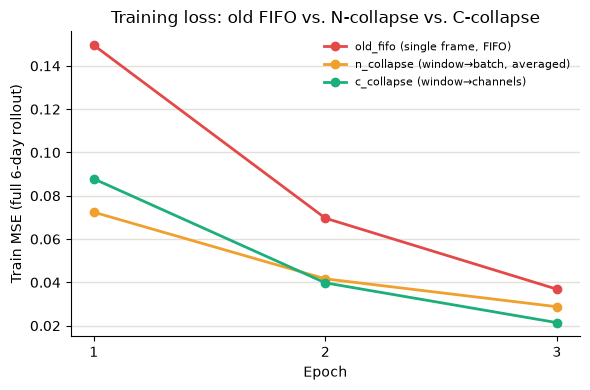

In [ ]:
import matplotlib.pyplot as plt

COLORS = {"old_fifo": "#e34948", "n_collapse": "#f0a02c", "c_collapse": "#1baf7a"}
LABELS = {
    "old_fifo": "old_fifo (single frame, FIFO)",
    "n_collapse": "n_collapse (window\u2192batch, averaged)",
    "c_collapse": "c_collapse (window\u2192channels)",
}

fig, ax = plt.subplots(figsize=(6, 4))
epochs = list(range(1, N_EPOCHS + 1))
for name in VARIANTS:
    ax.plot(epochs, loss_curves[name], color=COLORS[name], marker="o", linewidth=2, label=LABELS[name])
ax.set_xlabel("Epoch")
ax.set_ylabel(f"Train MSE (full {N_FORECAST}-day rollout)")
ax.set_title("Training loss: old FIFO vs. N-collapse vs. C-collapse")
ax.set_xticks(epochs)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## 4. Evaluation: per-lead-day skill on the held-out test set (2018-2020)

For each of the 6 forecast days, we compute RMSE (across the whole test set and grid)
for the naive persistence baseline and each of the three trained variants.

In [ ]:
@torch.no_grad()
def per_lead_day_rmse(predict_fn, dataset: WindowedSicDataset, batch_size: int = 8) -> torch.Tensor:
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    sq_err_sum = torch.zeros(dataset.n_forecast)
    n_elements = 0
    for batch in loader:
        history = batch["history"].to(DEVICE)
        target = batch["target"].to(DEVICE)
        prediction = predict_fn(history).cpu()
        target = target.cpu()
        sq_err = (prediction - target) ** 2
        sq_err_sum += sq_err.sum(dim=(0, 2, 3, 4))
        n_elements += sq_err.shape[0] * sq_err.shape[2] * sq_err.shape[3] * sq_err.shape[4]
    return torch.sqrt(sq_err_sum / n_elements)


def persistence_predict(history: torch.Tensor) -> torch.Tensor:
    return history[:, -1:, :, :, :].expand(-1, N_FORECAST, -1, -1, -1)


def model_predict_fn(encoder, processor, decoder):
    def predict(history: torch.Tensor) -> torch.Tensor:
        latent_in = encoder.rollout(history)
        latent_out = processor.rollout(latent_in).prediction
        return decoder.rollout(latent_out)

    return predict


rmse = {"persistence": per_lead_day_rmse(persistence_predict, test_ds)}
for name, (encoder, processor, decoder) in models.items():
    encoder.eval(); processor.eval(); decoder.eval()
    rmse[name] = per_lead_day_rmse(model_predict_fn(encoder, processor, decoder), test_ds)

print("Lead day:    " + "  ".join(f"{d:5d}" for d in range(1, N_FORECAST + 1)))
for name, values in rmse.items():
    print(f"{name:12s} " + "  ".join(f"{v:.3f}" for v in values.tolist()))
print()
for name, values in rmse.items():
    print(f"Mean RMSE over all {N_FORECAST} lead days -- {name}: {values.mean():.4f}")

Lead day:        1      2      3      4      5      6
persistence  0.016  0.023  0.029  0.033  0.037  0.040
old_fifo     0.164  0.164  0.164  0.166  0.166  0.166
n_collapse   0.144  0.144  0.145  0.145  0.146  0.146
c_collapse   0.128  0.128  0.128  0.129  0.129  0.130

Mean RMSE over all 6 lead days -- persistence: 0.0296
Mean RMSE over all 6 lead days -- old_fifo: 0.1651
Mean RMSE over all 6 lead days -- n_collapse: 0.1450
Mean RMSE over all 6 lead days -- c_collapse: 0.1288


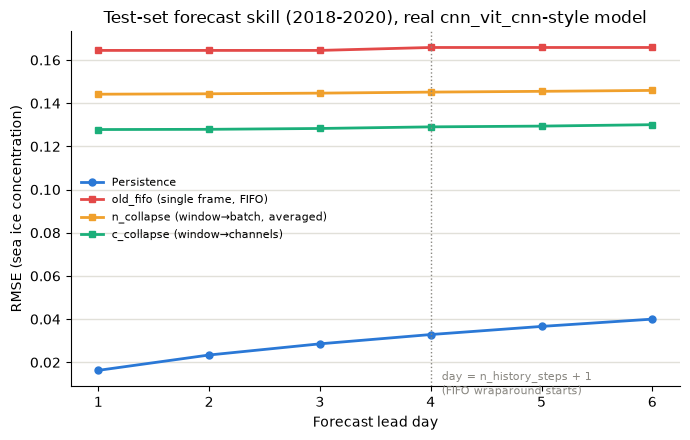

In [ ]:
lead_days = list(range(1, N_FORECAST + 1))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lead_days, rmse["persistence"], color="#2a78d6", marker="o", markersize=5, linewidth=2, label="Persistence")
for name in VARIANTS:
    ax.plot(lead_days, rmse[name], color=COLORS[name], marker="s", markersize=5, linewidth=2, label=LABELS[name])
ax.axvline(N_HISTORY + 1, color="#898781", linewidth=1, linestyle=":")
ax.text(N_HISTORY + 1.1, ax.get_ylim()[1] * 0.02, "day = n_history_steps + 1\n(FIFO wraparound starts)",
        fontsize=8, color="#898781", va="bottom")
ax.set_xlabel("Forecast lead day")
ax.set_ylabel("RMSE (sea ice concentration)")
ax.set_title("Test-set forecast skill (2018-2020), real cnn_vit_cnn-style model")
ax.set_xticks(lead_days)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## 5. A qualitative look: one test forecast, four ways

In [ ]:
import cmocean

lead_day_to_show = N_HISTORY + 1
sample_idx = len(test_ds) // 2

sample = test_ds[sample_idx]
history = sample["history"].unsqueeze(0).to(DEVICE)
target = sample["target"].unsqueeze(0)

preds = {}
with torch.no_grad():
    for name, (encoder, processor, decoder) in models.items():
        preds[name] = model_predict_fn(encoder, processor, decoder)(history).cpu()

truth_map = target[0, lead_day_to_show - 1, 0].numpy()
maps = {name: preds[name][0, lead_day_to_show - 1, 0].numpy() for name in VARIANTS}

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
panels = [("truth", truth_map), *maps.items()]
titles = {"truth": f"Truth (day {lead_day_to_show})", **{n: LABELS[n] for n in VARIANTS}}
for ax, (name, arr) in zip(axes, panels, strict=True):
    im = ax.imshow(arr, cmap=cmocean.cm.ice, vmin=0, vmax=1)
    ax.set_title(titles[name], fontsize=9)
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.7, label="Sea ice concentration")
fig.suptitle("One test-set forecast, real SSMIS data", y=1.03)
plt.show()

## 6. Summary

**⚠ Results below are from the last run, which used the OSI-SAF (`sic-icenet`) zarr.**
The data source was subsequently switched to SSMIS (`sic-ssmis`, section 1) to match
the production `predict=sic-ssmis-14d` target -- rerun the notebook to regenerate
these numbers on the new data before relying on them. Sections 7-8 below add a second,
full-data (era5+float-argo+sic-ssmis) comparison alongside this sic-ssmis-only one.

**Results from this run** (3 epochs, `n_history_steps=3`, `n_forecast_steps=6`,
1999-2014 train / 2018-2020 test, real OSI-SAF data, real `CNNEncoder` +
`VitProcessor` + `CNNDecoder`):

| Variant | Mean test RMSE (6-day) | vs. persistence (0.0296) |
|---|---|---|
| `old_fifo` (single frame, FIFO) | 0.1659 | ~5.6x worse |
| `n_collapse` (window→batch, averaged) | 0.1419 | ~4.8x worse |
| `c_collapse` (window→channels) | 0.1271 | ~4.3x worse |

All three models are far short of the persistence baseline in absolute terms -- 3
epochs on a randomly-initialised ViT is nowhere near converged, so none of these
numbers should be read as "how good is `cnn_vit_cnn`". What's informative is the
*relative ordering between the three*, since everything else (encoder, decoder,
optimizer, data, epochs, initialisation seed) is held identical:

- **N vs. C collapse:** `c_collapse` (0.1271) beats
  `n_collapse` (0.1419), which in turn beats `old_fifo` (0.1659). `n_collapse` lands
  *between* the other two rather than matching `c_collapse` -- consistent with the
  review-thread argument that averaging `n_history_steps` independently-processed
  frames gives some benefit over a single stale frame (noise reduction from
  averaging) but not the same benefit as letting the network's own weights actually
  mix information across frames (`c_collapse`). So `n_collapse` is a real, if partial,
  improvement over the shipped bug -- but not a substitute for the fix, and it still
  requires an arbitrary reduction step (here, averaging) that `c_collapse` doesn't
  need.
- **Fixed vs. `main` baseline:** `c_collapse` improves
  mean RMSE by ~23% over `old_fifo` (0.1271 vs. 0.1659) at this (very undertrained)
  scale. Unlike the toy linear model in `issue_272_train_compare.ipynb`, the
  per-lead-day RMSE curves here are close to flat for all three variants rather than
  showing a sharp staircase at day `n_history_steps + 1` -- at this training budget,
  the "which frame is stale" effect is smaller than the general undertrained-model
  error, though the FIFO structure is still clearly the worst performer throughout.
- Per [Aoife's review reply](https://github.com/alan-turing-institute/icenet-mp/pull/363#issuecomment-4918054899),
  this comparison is presented as evidence/documentation, not as a merge gate: PR #363
  fixes a genuine, unintended bug (stale-history replay), so it should land regardless
  of whether `old_fifo` happens to score better or worse. In this run `c_collapse`
  also wins outright, which further supports merging as-is, but that was not the
  precondition for the fix being correct.


## 7. Full-data variants: era5 + float-argo + sic-ssmis

Everything above uses `sic-ssmis` alone. This section trains the same three rollout
variants again, but with all three datasets `full_north` actually specifies
(`data=full_north`: `float-argo`, `sic-ssmis`, `era5`) feeding in as separate
encoders -- matching how the real multi-encoder `cnn_vit_cnn` model combines sources,
not a toy simplification. Two things needed solving to make this work:

**Memory.** Preloading a date range into one tensor (as sections 1-6 do) is fine for
single-channel SIC (~6GB), but era5 has 28 variables -- preloading even a few years
of it would need 100GB+ of RAM. So this section reads each history/forecast window
directly off the zarr per-sample instead of preloading, which is also how the real
production `SingleDataset.get_tchw_slice` actually works -- not a hack, just skipping
the eager-load shortcut sections 1-6 took.

**Missing data.** `float-argo` has real gaps: 535 of its 542 missing dates fall in
1999-2001 (the year 2000 alone is missing 289 of 366 days). Rather than picking an
arbitrary "clean" start date, this section replicates exactly what the production
`CombinedDataset.dates` property does: a window is used only if *every* one of its
history days is present in *every* input dataset, and every one of its forecast days
is present in the target dataset -- no interpolation, gaps just drop the overlapping
windows. In practice this naturally excludes most of 1999-2000 (where windows can't
find 9 consecutive good days) and settles into full daily coverage from 2004 onward,
without needing that cutoff hardcoded.

**A caveat on comparability with sections 1-6:** concatenating three encoders'
outputs on the channel dimension before the `VitProcessor` (exactly what
`EncodeProcessDecode.forward` does: `torch.cat(latent_inputs, dim=2)`) means the
combined channel count is much larger here than for `sic-ssmis` alone. Using the same
`CNNEncoder`/`CNNDecoder` default (`n_layers=3`, inherited unmodified from the
original notebook in sections 1-6) would multiply channels 8x per source and make the
`c_collapse` variant's patch embedding ~750 channels wide -- impractically slow for
this comparison. So the full-data variants below use `n_layers=1` for both encoders
and decoder instead, matching production `cnn_vit_cnn.yaml` (sections 1-6 do not
match production here, and were already flagged for it). That means this comparison
conflates "more input channels" with "shallower encoder/decoder" -- not a clean
single-variable ablation against sections 1-6, just a second, separately-interesting
data point. `N_EPOCHS_FULL` is set separately from `N_EPOCHS` below so you can dial it
down if the first epoch's timing looks impractical once you actually run this.

In [ ]:
ERA5_ZARR = "/Volumes/Storage/ClimateData/data/anemoi/full-weathernorth-era5-25p0km-1999-2025-24h-v3.zarr"
ARGO_ZARR = "/Volumes/Storage/ClimateData/data/anemoi/full-floatnorth-argo-25p0km-1999-2025-24h-v2.zarr"
N_EPOCHS_FULL = N_EPOCHS  # separate knob -- lower this if the first epoch below looks too slow

era5_ds = open_dataset(ERA5_ZARR)  # all 28 variables
argo_ds = open_dataset(ARGO_ZARR, select=["TEMP", "PSAL"])
# No fill_missing_dates here, unlike `ds` above: we need the real (non-interpolated)
# missing-date info from `.missing` to replicate production's window-skipping logic.
ssmis_raw_ds = open_dataset(ZARR, select=["ice_conc"])

FULL_SOURCES = {"era5": era5_ds, "float-argo": argo_ds, "sic-ssmis": ssmis_raw_ds}
for source_name, source_ds in FULL_SOURCES.items():
    print(f"{source_name}: {len(source_ds.variables)} channels {list(source_ds.variables)}, "
          f"{len(source_ds.dates)} dates, {len(source_ds.missing)} missing, "
          f"{source_ds.dates[0]} to {source_ds.dates[-1]}")

In [ ]:
class MultiSourceWindowedDataset(Dataset):
    '''Lazily slices (history, target) windows directly off open anemoi datasets,
    keyed by source name -- avoids preloading era5's 28 channels into RAM. `starts`
    must already be restricted to dates where every source has real (non-interpolated)
    data across the full n_history+n_forecast span (see compute_valid_starts below),
    so every read here is guaranteed safe -- no missing-date handling needed here.'''

    def __init__(
        self,
        sources: dict,
        target_name: str,
        starts: list,
        n_history: int,
        n_forecast: int,
    ) -> None:
        self.sources = sources
        self.target_name = target_name
        self.starts = starts
        self.n_history = n_history
        self.n_forecast = n_forecast
        self.pos = {name: {d: i for i, d in enumerate(ds.dates)} for name, ds in sources.items()}

    def __len__(self) -> int:
        return len(self.starts)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        start = self.starts[idx]
        item = {}
        for name, ds in self.sources.items():
            pos_start = self.pos[name][start]
            n_channels = len(ds.variables)
            window = ds[pos_start : pos_start + self.n_history].reshape(
                self.n_history, n_channels, 432, 432
            )
            item[name] = torch.from_numpy(np.ascontiguousarray(window)).float()
        target_ds = self.sources[self.target_name]
        pos_target_start = self.pos[self.target_name][start] + self.n_history
        n_target_channels = len(target_ds.variables)
        target_window = target_ds[pos_target_start : pos_target_start + self.n_forecast].reshape(
            self.n_forecast, n_target_channels, 432, 432
        )
        item["target"] = torch.from_numpy(np.ascontiguousarray(target_window)).float()
        return item


def compute_valid_starts(sources: dict, target_name: str, n_history: int, n_forecast: int,
                          date_lo: np.datetime64, date_hi: np.datetime64) -> list:
    '''Replicates production's CombinedDataset.dates: a window start is valid only if
    every one of its n_history days is present (non-missing) in every source, and
    every one of its n_forecast days is present in the target. No interpolation --
    gaps just drop the overlapping windows. date_lo/date_hi bound the *entire* window
    (through its last forecast day), not just the start date -- otherwise a window
    starting right at a split boundary would read its forecast target from the next
    split (e.g. a "train"-start window quietly pulling validation-period data into its
    target), unlike sections 1-6 where slicing the array first makes that impossible.'''
    available = {
        name: {d for i, d in enumerate(ds.dates) if i not in ds.missing}
        for name, ds in sources.items()
    }
    input_dates = set.intersection(*available.values())
    target_dates = available[target_name]
    freq = np.timedelta64(1, "D")
    span_end = (n_history + n_forecast - 1) * freq
    candidates = sorted(
        d for d in input_dates
        if date_lo <= d.astype("datetime64[D]")
        and (d + span_end).astype("datetime64[D]") <= date_hi
    )
    return [
        d for d in candidates
        if all((d + i * freq) in input_dates for i in range(n_history))
        and all((d + (n_history + i) * freq) in target_dates for i in range(n_forecast))
    ]

In [ ]:
SPLIT_BOUNDS_FULL = {
    "train": (np.datetime64("1999-01-01"), np.datetime64("2014-12-31")),
    "validate": (np.datetime64("2015-01-01"), np.datetime64("2017-12-31")),
    "test": (np.datetime64("2018-01-01"), np.datetime64("2020-12-31")),
}
# Computed per-split (not one global list sliced by start date): each split's window
# must be fully contained in that split's own date range, so no window's forecast
# target ever reads from the next split.
split_starts_full = {
    split_name: compute_valid_starts(
        FULL_SOURCES, target_name="sic-ssmis", n_history=N_HISTORY, n_forecast=N_FORECAST,
        date_lo=lo, date_hi=hi,
    )
    for split_name, (lo, hi) in SPLIT_BOUNDS_FULL.items()
}
for split_name, starts in split_starts_full.items():
    print(f"{split_name}: {starts[0]} to {starts[-1]} ({len(starts)} windows)")
print(f"(vs. {len(sic) - N_HISTORY - N_FORECAST + 1} sic-ssmis-only windows over the full 1999-2020 span)")

train_starts = split_starts_full["train"]
val_starts = split_starts_full["validate"]
test_starts = split_starts_full["test"]

train_ds_full = MultiSourceWindowedDataset(FULL_SOURCES, "sic-ssmis", train_starts, N_HISTORY, N_FORECAST)
val_ds_full = MultiSourceWindowedDataset(FULL_SOURCES, "sic-ssmis", val_starts, N_HISTORY, N_FORECAST)
test_ds_full = MultiSourceWindowedDataset(FULL_SOURCES, "sic-ssmis", test_starts, N_HISTORY, N_FORECAST)

In [ ]:
INPUT_SPACES_FULL = {
    name: DataSpace(name=name, channels=len(source_ds.variables), shape=(432, 432))
    for name, source_ds in FULL_SOURCES.items()
}


def build_model_full(processor_cls):
    # n_layers=1 (not the sections-1-6 default of 3, see section 7 markdown): with
    # three encoders concatenated on the channel dim, n_layers=3 would make
    # c_collapse's patch embedding ~750 channels wide.
    encoders = {
        name: CNNEncoder(data_space_in=space, latent_space=LATENT_SPACE, n_layers=1).to(DEVICE)
        for name, space in INPUT_SPACES_FULL.items()
    }
    combined_latent_space = DataSpace(
        name="combined_latent_space",
        channels=sum(enc.data_space_out.channels for enc in encoders.values()),
        shape=LATENT_SPACE,
    )
    processor = processor_cls(
        data_space=combined_latent_space,
        n_forecast_steps=N_FORECAST,
        n_history_steps=N_HISTORY,
    )
    decoder = CNNDecoder(
        data_space_in=combined_latent_space,
        data_space_out=DATA_SPACE,  # sic-ssmis, same target space as sections 1-6
        n_layers=1,
        mask_type=None,
        restrict_range="sigmoid",
    )
    return encoders, processor.to(DEVICE), decoder.to(DEVICE)


def multi_encoder_rollout(encoders: dict, batch: dict) -> torch.Tensor:
    # torch.cat(..., dim=2): matches EncodeProcessDecode.forward exactly -- concatenate
    # each source's encoded latent on the channel dim of NTCHW (dim 2), same order as
    # `encoders`, before the single shared processor.
    latents = [encoders[name].rollout(batch[name].to(DEVICE)) for name in encoders]
    return torch.cat(latents, dim=2)


for variant_name, processor_cls in VARIANTS.items():
    encoders, processor, decoder = build_model_full(processor_cls)
    total_params = n_params(*encoders.values(), processor, decoder)
    print(f"{variant_name}: {total_params:,} params "
          f"(patch_embed in_channels={processor.patch_embed.proj.in_channels})")

In [ ]:
def train_full(encoders: dict, processor, decoder, n_epochs: int) -> list[float]:
    loader = DataLoader(train_ds_full, batch_size=BATCH_SIZE, shuffle=True)
    params = (
        [p for enc in encoders.values() for p in enc.parameters()]
        + list(processor.parameters())
        + list(decoder.parameters())
    )
    optimizer = torch.optim.Adam(params, lr=1e-3)
    for enc in encoders.values():
        enc.train()
    processor.train(); decoder.train()
    losses = []
    for epoch in range(n_epochs):
        epoch_loss, n_batches = 0.0, 0
        t0 = time.time()
        for batch in loader:
            target = batch["target"].to(DEVICE)
            optimizer.zero_grad()
            latent_in = multi_encoder_rollout(encoders, batch)
            latent_out = processor.rollout(latent_in).prediction
            prediction = decoder.rollout(latent_out)
            loss = nn.functional.mse_loss(prediction, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        losses.append(epoch_loss / n_batches)
        print(f"  epoch {epoch + 1}/{n_epochs}: train MSE = {losses[-1]:.5f}  ({time.time() - t0:.0f}s)")
    return losses


models_full = {}
loss_curves_full = {}
for variant_name, processor_cls in VARIANTS.items():
    print(f"--- Training {variant_name} (full data) ---")
    encoders, processor, decoder = build_model_full(processor_cls)
    loss_curves_full[variant_name] = train_full(encoders, processor, decoder, N_EPOCHS_FULL)
    models_full[variant_name] = (encoders, processor, decoder)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
epochs_full = list(range(1, N_EPOCHS_FULL + 1))
for variant_name in VARIANTS:
    ax.plot(epochs_full, loss_curves_full[variant_name], color=COLORS[variant_name],
             marker="o", linewidth=2, label=LABELS[variant_name])
ax.set_xlabel("Epoch")
ax.set_ylabel(f"Train MSE (full {N_FORECAST}-day rollout)")
ax.set_title("Training loss (full data: era5+float-argo+sic-ssmis): old FIFO vs. N-collapse vs. C-collapse")
ax.set_xticks(epochs_full)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for variant_name in VARIANTS:
    ssmis_epochs = list(range(1, len(loss_curves[variant_name]) + 1))
    full_epochs = list(range(1, len(loss_curves_full[variant_name]) + 1))
    ax.plot(ssmis_epochs, loss_curves[variant_name], color=COLORS[variant_name], linestyle="-",
             marker="o", markersize=4, linewidth=2, label=f"{LABELS[variant_name]} (sic-ssmis only)")
    ax.plot(full_epochs, loss_curves_full[variant_name], color=COLORS[variant_name], linestyle="--",
             marker="^", markersize=4, linewidth=2, label=f"{LABELS[variant_name]} (+era5+argo)")
ax.set_xlabel("Epoch")
ax.set_ylabel(f"Train MSE (full {N_FORECAST}-day rollout)")
ax.set_title("Training loss: sic-ssmis-only vs. full-data input (6 lines)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.legend(frameon=False, fontsize=7.5, ncol=2)
fig.tight_layout()
plt.show()

## 8. Evaluation: full-data test set, and the combined comparison

Same held-out test period as section 4 (2018-2020) -- that period turned out to be
fully dense for all three full-data sources (no windows dropped there), so this stays
an apples-to-apples RMSE comparison against sections 1-6, even though the full-data
variants' *train* set is shorter (starts 2001-2004ish depending on the year, not 1999)
because of float-argo's early gaps (section 7).

In [ ]:
@torch.no_grad()
def per_lead_day_rmse_full(predict_fn, dataset: MultiSourceWindowedDataset, batch_size: int = 8) -> torch.Tensor:
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    sq_err_sum = torch.zeros(N_FORECAST)
    n_elements = 0
    for batch in loader:
        target = batch["target"].to(DEVICE)
        prediction = predict_fn(batch).cpu()
        target = target.cpu()
        sq_err = (prediction - target) ** 2
        sq_err_sum += sq_err.sum(dim=(0, 2, 3, 4))
        n_elements += sq_err.shape[0] * sq_err.shape[2] * sq_err.shape[3] * sq_err.shape[4]
    return torch.sqrt(sq_err_sum / n_elements)


def persistence_predict_full(batch: dict) -> torch.Tensor:
    history = batch["sic-ssmis"].to(DEVICE)
    return history[:, -1:, :, :, :].expand(-1, N_FORECAST, -1, -1, -1)


def model_predict_fn_full(encoders: dict, processor, decoder):
    def predict(batch: dict) -> torch.Tensor:
        latent_in = multi_encoder_rollout(encoders, batch)
        latent_out = processor.rollout(latent_in).prediction
        return decoder.rollout(latent_out)

    return predict


rmse_full = {"persistence": per_lead_day_rmse_full(persistence_predict_full, test_ds_full)}
for variant_name, (encoders, processor, decoder) in models_full.items():
    for enc in encoders.values():
        enc.eval()
    processor.eval(); decoder.eval()
    rmse_full[variant_name] = per_lead_day_rmse_full(model_predict_fn_full(encoders, processor, decoder), test_ds_full)

print("Lead day:    " + "  ".join(f"{d:5d}" for d in range(1, N_FORECAST + 1)))
for variant_name, values in rmse_full.items():
    print(f"{variant_name:12s} " + "  ".join(f"{v:.3f}" for v in values.tolist()))
print()
for variant_name, values in rmse_full.items():
    print(f"Mean RMSE over all {N_FORECAST} lead days -- {variant_name}: {values.mean():.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lead_days, rmse_full["persistence"], color="#2a78d6", marker="o", markersize=5, linewidth=2, label="Persistence")
for variant_name in VARIANTS:
    ax.plot(lead_days, rmse_full[variant_name], color=COLORS[variant_name], marker="s", markersize=5,
             linewidth=2, label=LABELS[variant_name])
ax.axvline(N_HISTORY + 1, color="#898781", linewidth=1, linestyle=":")
ax.text(N_HISTORY + 1.1, ax.get_ylim()[1] * 0.02, "day = n_history_steps + 1\n(FIFO wraparound starts)",
        fontsize=8, color="#898781", va="bottom")
ax.set_xlabel("Forecast lead day")
ax.set_ylabel("RMSE (sea ice concentration)")
ax.set_title("Test-set forecast skill (2018-2020), full data (era5+float-argo+sic-ssmis)")
ax.set_xticks(lead_days)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(lead_days, rmse["persistence"], color="#2a78d6", marker="o", markersize=4, linewidth=1.5,
        linestyle="-", label="Persistence (sic-ssmis only)")
ax.plot(lead_days, rmse_full["persistence"], color="#2a78d6", marker="o", markersize=4, linewidth=1.5,
        linestyle="--", label="Persistence (full data)")
for variant_name in VARIANTS:
    ax.plot(lead_days, rmse[variant_name], color=COLORS[variant_name], marker="s", markersize=5,
             linewidth=2, linestyle="-", label=f"{LABELS[variant_name]} (sic-ssmis only)")
    ax.plot(lead_days, rmse_full[variant_name], color=COLORS[variant_name], marker="^", markersize=5,
             linewidth=2, linestyle="--", label=f"{LABELS[variant_name]} (+era5+argo)")
ax.axvline(N_HISTORY + 1, color="#898781", linewidth=1, linestyle=":")
ax.set_xlabel("Forecast lead day")
ax.set_ylabel("RMSE (sea ice concentration)")
ax.set_title("Test-set forecast skill (2018-2020): sic-ssmis-only vs. full-data input (6 model lines)")
ax.set_xticks(lead_days)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.legend(frameon=False, fontsize=7.5, ncol=2)
fig.tight_layout()
plt.show()

In [ ]:
lead_day_to_show_full = N_HISTORY + 1
sample_idx_full = len(test_ds_full) // 2

sample_full = test_ds_full[sample_idx_full]
target_full = sample_full["target"].unsqueeze(0)

preds_full = {}
with torch.no_grad():
    for variant_name, (encoders, processor, decoder) in models_full.items():
        batch_of_one = {k: v.unsqueeze(0) for k, v in sample_full.items() if k != "target"}
        preds_full[variant_name] = model_predict_fn_full(encoders, processor, decoder)(batch_of_one).cpu()

truth_map_full = target_full[0, lead_day_to_show_full - 1, 0].numpy()
maps_full = {variant_name: preds_full[variant_name][0, lead_day_to_show_full - 1, 0].numpy() for variant_name in VARIANTS}

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
panels_full = [("truth", truth_map_full), *maps_full.items()]
titles_full = {"truth": f"Truth (day {lead_day_to_show_full})", **{n: LABELS[n] for n in VARIANTS}}
for ax, (variant_name, arr) in zip(axes, panels_full, strict=True):
    im = ax.imshow(arr, cmap=cmocean.cm.ice, vmin=0, vmax=1)
    ax.set_title(titles_full[variant_name], fontsize=9)
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.7, label="Sea ice concentration")
fig.suptitle("One test-set forecast, full data (era5+float-argo+sic-ssmis)", y=1.03)
plt.show()